In [1]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 641.3 kB/s eta 0:00:00


This starter notebook for the [2026 NeuroGolf Championship](https://www.kaggle.com/competitions/neurogolf-2026) is designed to help contestants verify the functional correctness of their networks.  It allows one to load example pairs for a task, visualize them, and test whether a candidate network produces expected results across all public competition benchmarks.

## Enter a task number (between 1 and 400):

In [2]:
task_num = 0  # Task 0 is just an illustrative example (and not eligible for points)

## Color legend

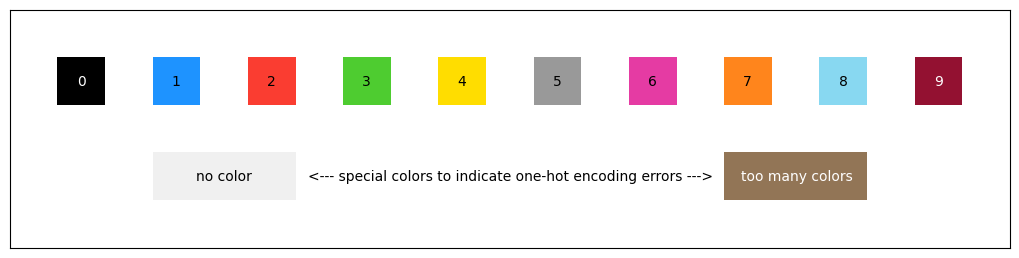

In [3]:
import sys
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import *
show_legend()

## Example <input, output> pairs

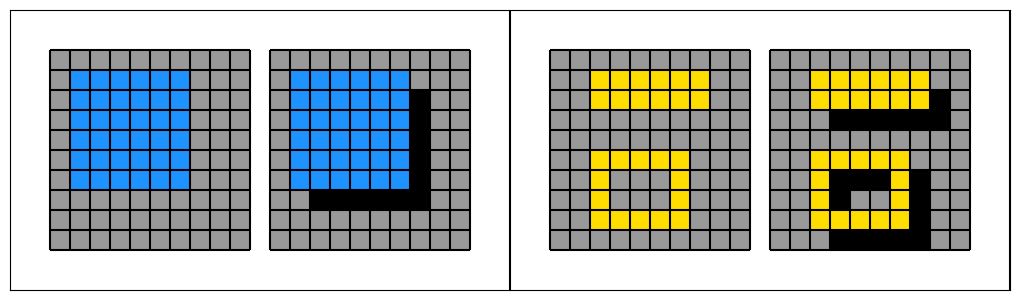

In [4]:
examples = load_examples(task_num)
show_examples(examples['train'] + examples['test'])

## Define your network to solve the task

The code below uses a utility we've provided to help you create [single-layer convolutional networks](https://en.wikipedia.org/wiki/Convolutional_layer).  It may be possible to solve other tasks in a similar way, but most will require more complicated architectures!

In [5]:
def weight(channel_out, channel_in, kernel_coord):
  if kernel_coord == ( 0,  0) and channel_in == channel_out: return 1.0
  if kernel_coord == ( 0,  0) and channel_in != 5 and channel_out == 0: return -1.0
  if kernel_coord == (-1, -1) and channel_in != 5 and channel_out == 0: return 1.0
  if kernel_coord == (-1, -1) and channel_in != 5 and channel_out == 5: return -1.0
  return 0.0

network = single_layer_conv2d_network(weight, kernel_size=3)

## Verify your network

In [6]:
verify_network(network, task_num, examples)

Results on ARC-AGI examples: 2 pass, 0 fail
Results on ARC-GEN examples: 1 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name    Type    Forward_MACs    FPercent    Memory    MPercent      Params  PPercent    InShape     OutShape
------  ------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
Conv_0  Conv    810,000         100.00%     39,600    100.00%          900  100.00%     1x10x30x30  1x10x30x30
Total   _       810,000         100%        39,600    100%             900  100%        _           _

It appears to require 0 bytes + 900 params, yielding 18.198 points.

Next steps:
 * Click the link below to download task000.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle competition so that it can be officially scored.



/kaggle/working/task000.onnx